In [1]:
import sys
sys.path.append("../src")

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from model import CIFAR10ResNet18
from dataset import get_dataloaders

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print(f"Using device: {device}")

model = CIFAR10ResNet18(num_classes=10, freeze_backbone=False).to(device)
model.load_state_dict(torch.load("../outputs/best_model.pt", map_location=device))
model.eval()

_, _, test_loader = get_dataloaders(data_dir="../data", batch_size=64, seed=42)
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

Using device: xpu


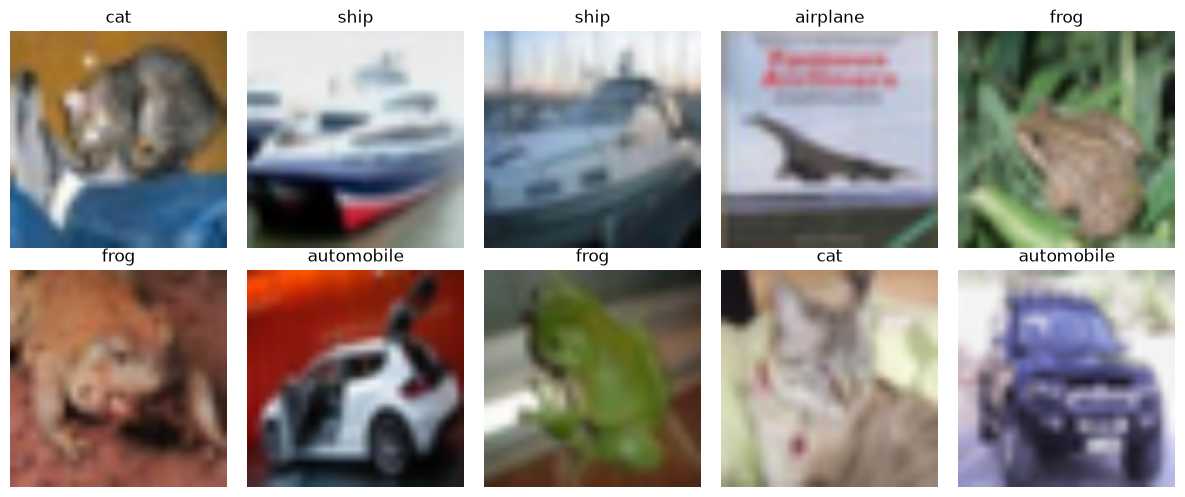

In [2]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor):
    img = img_tensor * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

images, labels = next(iter(test_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]))
    ax.set_title(classes[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1).cpu()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [4]:
test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

Test Accuracy: 0.9453

              precision    recall  f1-score   support

    airplane     0.9546    0.9470    0.9508      1000
  automobile     0.9672    0.9730    0.9701      1000
        bird     0.9443    0.9320    0.9381      1000
         cat     0.8862    0.8720    0.8790      1000
        deer     0.9332    0.9500    0.9415      1000
         dog     0.9021    0.9120    0.9070      1000
        frog     0.9663    0.9740    0.9701      1000
       horse     0.9657    0.9580    0.9618      1000
        ship     0.9632    0.9690    0.9661      1000
       truck     0.9699    0.9660    0.9679      1000

    accuracy                         0.9453     10000
   macro avg     0.9453    0.9453    0.9453     10000
weighted avg     0.9453    0.9453    0.9453     10000



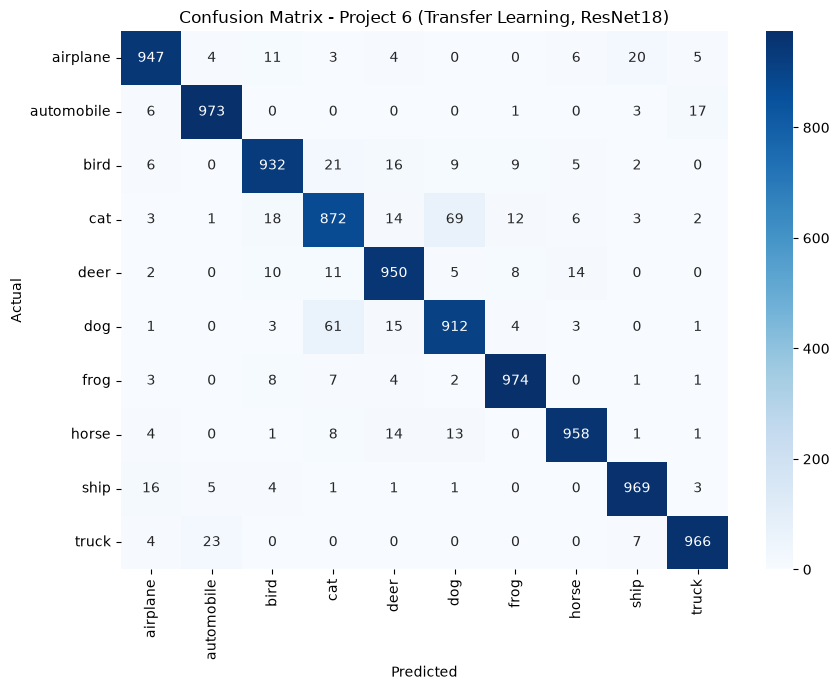

In [5]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Project 6 (Transfer Learning, ResNet18)")
plt.tight_layout()
plt.show()

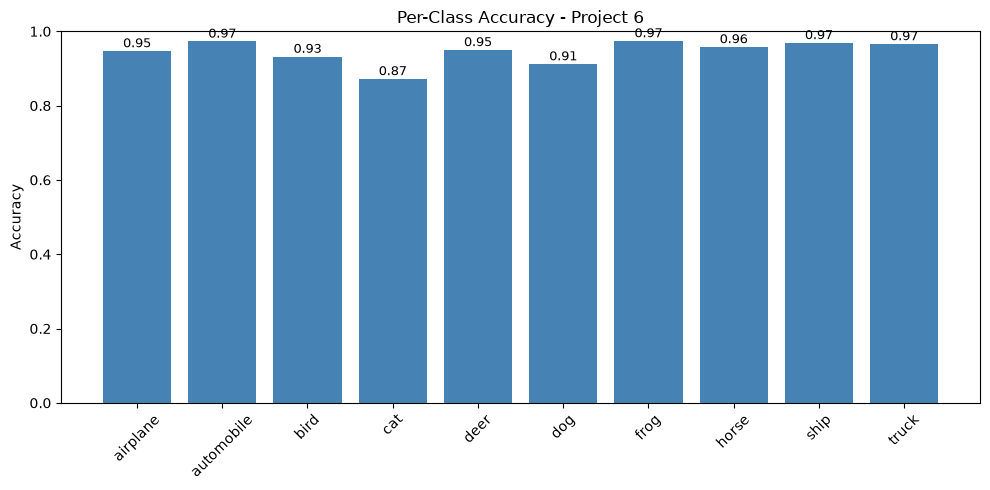

In [6]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, per_class_acc, color="steelblue")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy - Project 6")
plt.xticks(rotation=45)
plt.ylim(0, 1)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

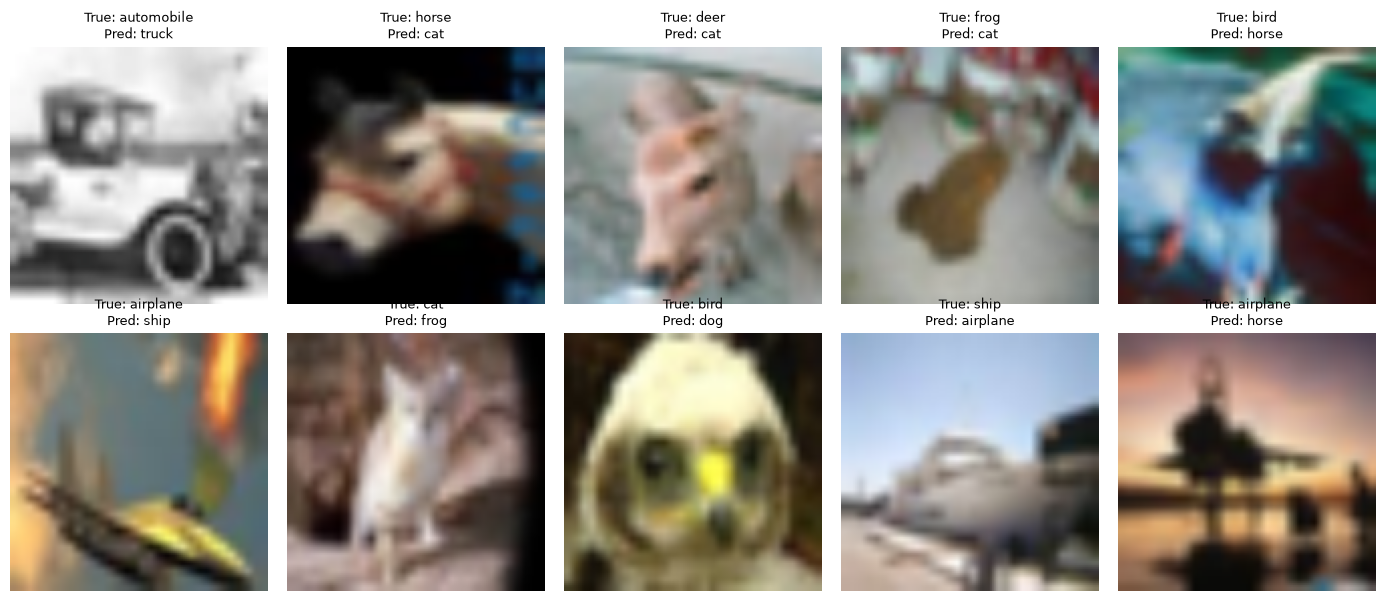

In [7]:
misclassified_idx = np.where(all_preds != all_labels)[0][:10]

all_test_images = []
for images, _ in test_loader:
    all_test_images.append(images)
all_test_images = torch.cat(all_test_images)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flat, misclassified_idx):
    ax.imshow(denormalize(all_test_images[idx]))
    ax.set_title(f"True: {classes[all_labels[idx]]}\nPred: {classes[all_preds[idx]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

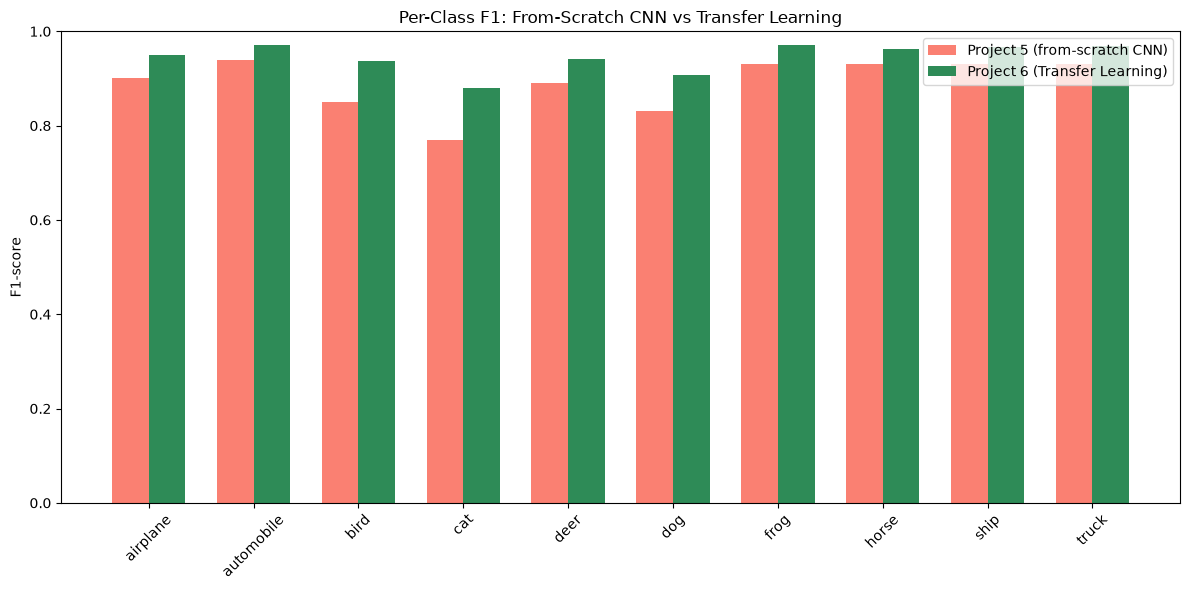

Project 5 overall test accuracy: 0.8888
Project 6 overall test accuracy: 0.9453


In [8]:
project5_f1 = {
    "airplane": 0.90, "automobile": 0.94, "bird": 0.85, "cat": 0.77, "deer": 0.89,
    "dog": 0.83, "frog": 0.93, "horse": 0.93, "ship": 0.93, "truck": 0.93,
}

p6_report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
project6_f1 = {c: p6_report[c]["f1-score"] for c in classes}

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, [project5_f1[c] for c in classes], width, label="Project 5 (from-scratch CNN)", color="salmon")
plt.bar(x + width/2, [project6_f1[c] for c in classes], width, label="Project 6 (Transfer Learning)", color="seagreen")
plt.xticks(x, classes, rotation=45)
plt.ylabel("F1-score")
plt.title("Per-Class F1: From-Scratch CNN vs Transfer Learning")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Project 5 overall test accuracy: 0.8888")
print(f"Project 6 overall test accuracy: {test_acc:.4f}")